# OBJECTIVE 6: 
#### The Severity Prediction (Hard) Build a model that predicts, for flights that are already delayed, how bad that delay is actually going to get. Visualize which factors drive severity the most — and tell us when a delayed traveler should start panicking versus when they can relax and grab a coffee.

Loaded dataset from: ../data/processed/merged_data.csv
Dataset Shape: (5574612, 22)
Post-cleaning Shape: (1951813, 22)


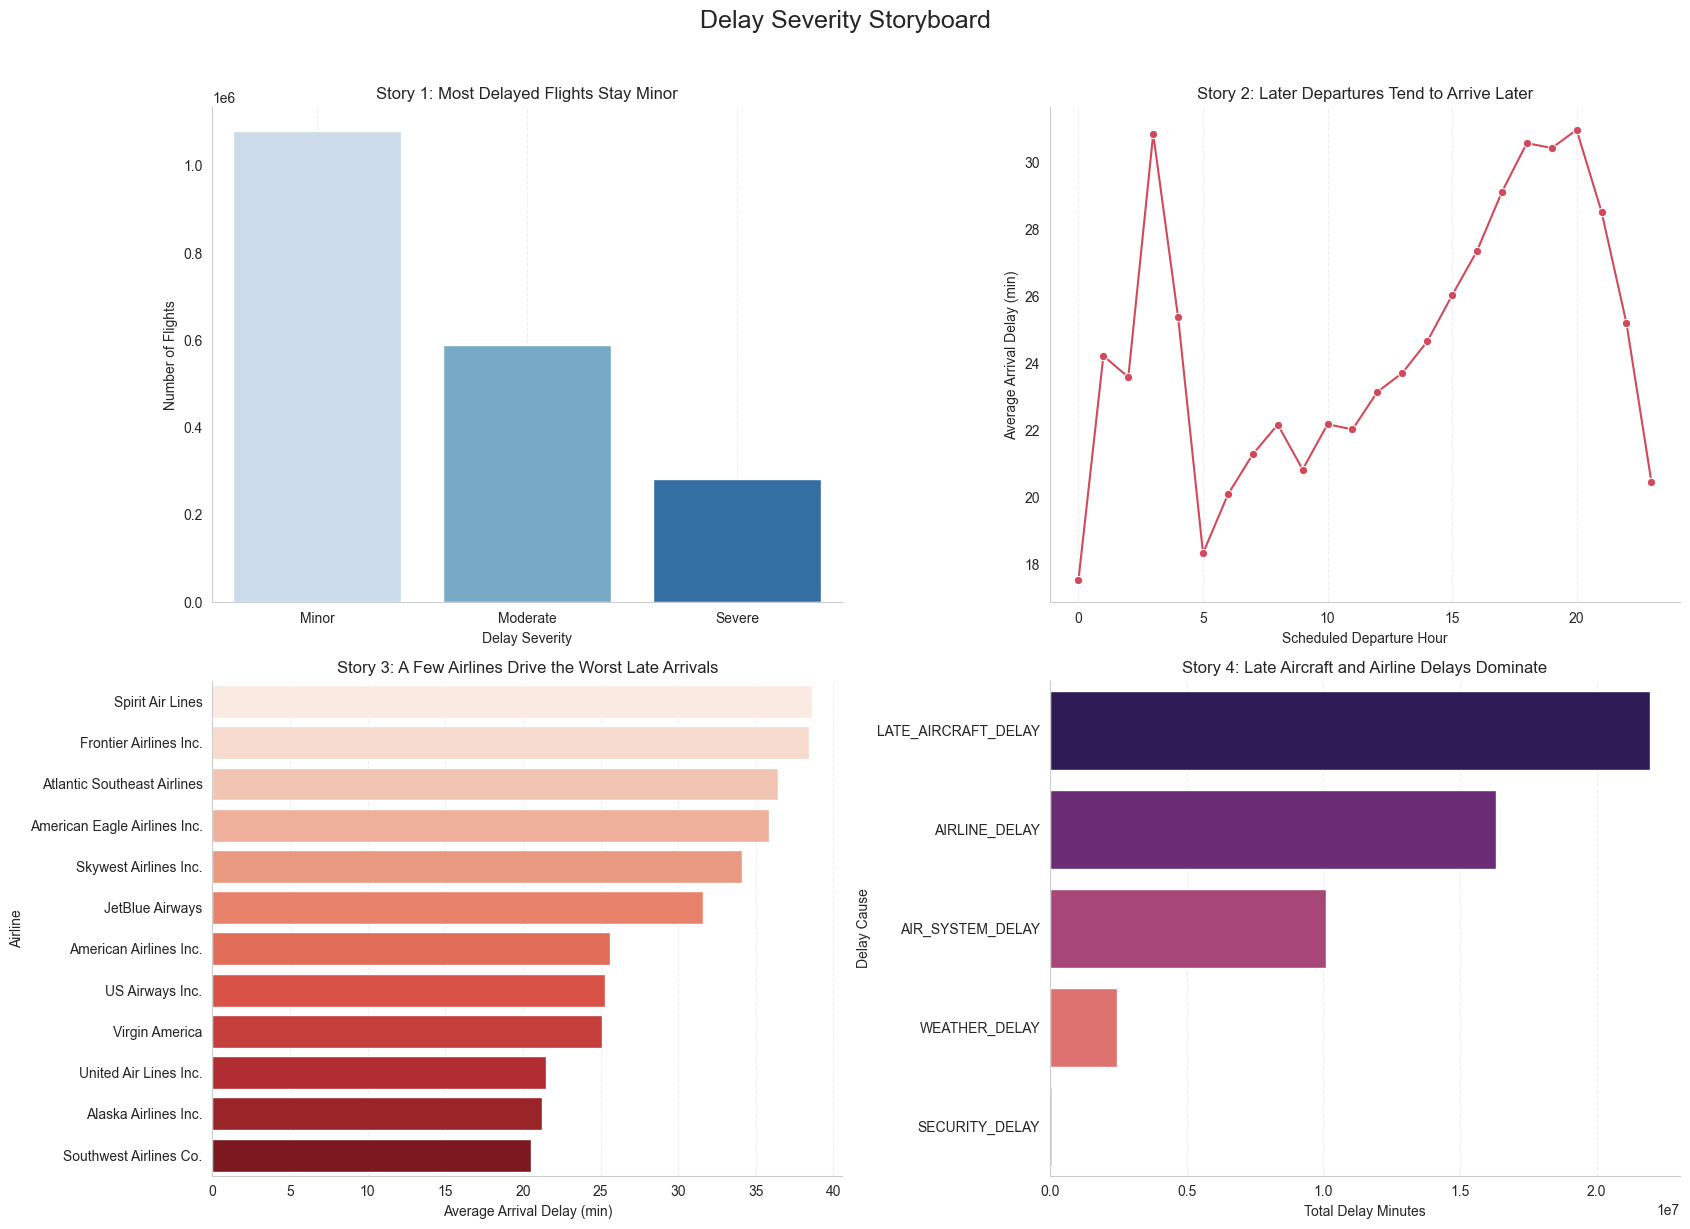

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

sns.set_style("whitegrid")


# ==========================================
# 2. Load Dataset
# ==========================================
possible_paths = ["../data/processed/merged_data.csv", "data/processed/merged_data.csv", "merged_data.csv"]
df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f"Loaded dataset from: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError("merged_data.csv not found in expected locations")

print("Dataset Shape:", df.shape)


# ==========================================
# 3. Data Cleaning (Objective-aligned)
# ==========================================
# Keep non-diverted flights
if "DIVERTED" in df.columns:
    df = df[df["DIVERTED"] == 0].copy()

# Keep non-cancelled flights if cancellation signal exists
if "CANCELLED" in df.columns:
    df["CANCELLED"] = pd.to_numeric(df["CANCELLED"], errors="coerce").fillna(0)
    df = df[df["CANCELLED"] == 0].copy()

# Fill delay-cause columns
delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

for col in delay_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Ensure numeric delay fields
for col in ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "DISTANCE", "FLIGHT_NUMBER", "scheduled_dep_hour", "MONTH", "DAY_OF_WEEK"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# For Objective 6: flights already delayed at departure
if "DEPARTURE_DELAY" in df.columns:
    df = df[df["DEPARTURE_DELAY"] > 0].copy()

# Keep rows with target label
df["delay_severity"] = df["delay_severity"].astype("string")
df = df[df["delay_severity"].notna()].copy()

print("Post-cleaning Shape:", df.shape)


# ==========================================
# 4. Story-Style Visualization (Narrative EDA)
# ==========================================
# Story frame: what happens, when, who, and why
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# A) What happens? Severity distribution
severity_order = [s for s in ["Minor", "Moderate", "Severe"] if s in set(df["delay_severity"].astype(str))]
if not severity_order:
    severity_order = sorted(df["delay_severity"].astype(str).unique())

sns.countplot(data=df, x="delay_severity", order=severity_order, palette="Blues", ax=axes[0, 0])
axes[0, 0].set_title("Story 1: Most Delayed Flights Stay Minor")
axes[0, 0].set_xlabel("Delay Severity")
axes[0, 0].set_ylabel("Number of Flights")

# B) When does it get worse?
hour_delay = (
    df.groupby("scheduled_dep_hour", as_index=False)["ARRIVAL_DELAY"]
      .mean()
      .sort_values("scheduled_dep_hour")
)
sns.lineplot(data=hour_delay, x="scheduled_dep_hour", y="ARRIVAL_DELAY", marker="o", color="#D1495B", ax=axes[0, 1])
axes[0, 1].set_title("Story 2: Later Departures Tend to Arrive Later")
axes[0, 1].set_xlabel("Scheduled Departure Hour")
axes[0, 1].set_ylabel("Average Arrival Delay (min)")

# C) Which airlines are riskier?
airline_delay = (
    df.groupby("AIRLINE_NAME", as_index=False)["ARRIVAL_DELAY"]
      .mean()
      .sort_values("ARRIVAL_DELAY", ascending=False)
      .head(12)
)
sns.barplot(data=airline_delay, x="ARRIVAL_DELAY", y="AIRLINE_NAME", palette="Reds", ax=axes[1, 0])
axes[1, 0].set_title("Story 3: A Few Airlines Drive the Worst Late Arrivals")
axes[1, 0].set_xlabel("Average Arrival Delay (min)")
axes[1, 0].set_ylabel("Airline")

# D) Why do delays explode?
delay_causes = df[delay_cols].sum().sort_values(ascending=False)
sns.barplot(x=delay_causes.values, y=delay_causes.index, palette="magma", ax=axes[1, 1])
axes[1, 1].set_title("Story 4: Late Aircraft and Airline Delays Dominate")
axes[1, 1].set_xlabel("Total Delay Minutes")
axes[1, 1].set_ylabel("Delay Cause")

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.grid(axis="y", visible=False)

plt.suptitle("Delay Severity Storyboard", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


# ==========================================
# 5. Encode Categorical Features (FIXED)
# ==========================================
cat_cols = [
    "AIRLINE_NAME",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ORIGIN_CITY",
    "ORIGIN_STATE",
    "route"
]

# Key fix: force uniform string dtype before LabelEncoder
for col in cat_cols:
    df[col] = df[col].astype("string").fillna("Unknown").astype(str)
    col_encoder = LabelEncoder()
    df[col] = col_encoder.fit_transform(df[col])

# Encode target consistently
target_encoder = LabelEncoder()
df["delay_severity_encoded"] = target_encoder.fit_transform(df["delay_severity"].astype(str))


# ==========================================
# 6. Feature Selection
# ==========================================
features = [
    "MONTH",
    "DAY_OF_WEEK",
    "AIRLINE_NAME",
    "FLIGHT_NUMBER",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "scheduled_dep_hour",
    "DEPARTURE_DELAY",
    "DISTANCE",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

model_df = df.dropna(subset=features + ["delay_severity_encoded"]).copy()

X = model_df[features]
y = model_df["delay_severity_encoded"]

print("Modeling rows:", len(model_df))


# ==========================================
# 7. Train Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 8. Train XGBoost Model
# ==========================================
model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# ==========================================
# 9. Prediction
# ==========================================
y_pred = model.predict(X_test)


# ==========================================
# 10. Model Evaluation
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy, 4))

label_names = target_encoder.classes_

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_pred)
print()
print("Confusion Matrix:")
print(cm)


# ==========================================
# 11. Confusion Matrix Visualization
# ==========================================
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ==========================================
# 12. Feature Importance
# ==========================================
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure(figsize=(9, 6))
feat_imp.plot(kind="barh", color="#457B9D")
plt.title("Feature Importance for Delay Severity")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

